<a href="https://colab.research.google.com/github/JNprog8/people-detection/blob/main/crowd_counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from scipy.spatial import KDTree
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# IMPORTAR DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# NOTA:
# Dar acceso al drive (dirección: '/content/drive/MyDrive/')
# Tener en MyDrive, la carpeta 'ia-competencia' (tal que: .../MyDrive/ia-competencia)
# Dentro de 'ia-competencia' el dataset 'parte-b' (tal que: .../ia-competencia/part_B_final)

# SI NO SE TIENE EL DATASET SE PUEDE DESCARGAR DIRECTAMENTE AL NOTEBOOK
#!wget -O ShanghaiTech.zip "https://www.dropbox.com/scl/fi/dkj5kulc9zj0rzesslck8/ShanghaiTech_Crowd_Counting_Dataset.zip?rlkey=ymbcj50ac04uvqn8p49j9af5f&dl=1"
#!unzip -q ShanghaiTech.zip -d ShanghaiTech

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# CONFIGURACIÓN DE PARÁMETROS

In [ ]:
class Config:

    # Rutas de datos
    DRIVE_IMG = '/content/drive/MyDrive/IA/Imagenes/'
    DRIVE_SAVE = '/content/drive/MyDrive/ia-competencia'
    DRIVE_WEIGHTS = '/content/drive/MyDrive/ia-competencia/saved_weights/csrnet_best.weights.h5'
    DRIVE_BASE = '/content/drive/MyDrive/ia-competencia/part_B_final'
    TRAIN_IMG_DIR = '/content/drive/MyDrive/ia-competencia/part_B_final/train_data/images/'
    TRAIN_GT_DIR = '/content/drive/MyDrive/ia-competencia/part_B_final/train_data/ground_truth/'
    TEST_IMG_DIR = '/content/drive/MyDrive/ia-competencia/part_B_final/test_data/images/'
    TEST_GT_DIR = '/content/drive/MyDrive/ia-competencia/part_B_final/test_data/ground_truth/'

    # Parámetros de imagen
    IN_H, IN_W = 768, 1024  # Tamaño entrada
    DOWNSAMPLE = 8          # Factor de reducción

    # Parámetros de visualización
    NUM_TEST_IMAGES = 20        # Número de imágenes a visualizar
    FIGURE_WIDTH = 20           # Ancho de figura
    FIGURE_HEIGHT_PER_ROW = 3   # Alto por fila de imagen

    # Parámetros de entrenamiento
    BATCH_SIZE = 4
    LEARNING_RATE = 4e-5    # # LR para entrenamiento base
    FINE_TUNE_LR = 4e-6     # LR para fine-tuning
    EPOCHS = 10             # Epochs para entrenamiento base
    FINE_TUNE_EPOCHS = 12   # Epochs adicionales con backbone

    # Parámetros de kernels de densidad
    BETA = 0.2          # Factor para kernels adaptativos (factor bajo (menor) = menos sobreestimación)
    SIGMA = 3           # Sigma fijo para pocos puntos (radio gaussiano en los mapas de densidad)
    K_NEIGHBORS = 4     # Vecinos para kernels adaptativos (kernel adapativos +)

    # #=========================== Configuracion MAYOR Precision pero mas costoso ============================
    # # Salida: Out of memory while trying to allocate 15573928648 bytes
    # # Entrenamiento mas largo y gradual
    # BATCH_SIZE = 8          # Gradientes más estables
    # LEARNING_RATE = 2e-5    # LR muy bajo desde inicio
    # FINE_TUNE_LR = 2e-6     # Fine-tuning ultra-conservador
    # EPOCHS = 15             # Más epochs en fase 1
    # FINE_TUNE_EPOCHS = 30   # Fine-tuning extenso

    # BETA = 0.1              # Kernels muy pequeños
    # SIGMA = 2               # Mínima dispersión
    # K_NEIGHBORS = 5         # Más vecinos para mejor promedio

    @property
    def OUT_H(self): return self.IN_H // self.DOWNSAMPLE

    @property
    def OUT_W(self): return self.IN_W // self.DOWNSAMPLE

    @property
    def CHECKPOINT_PATH(self):
        path = os.path.join(self.DRIVE_SAVE, 'saved_weights', 'csrnet_best.weights.h5')
        os.makedirs(os.path.dirname(path), exist_ok=True)
        return path

config = Config()

# FUNCIONES DE PREPROCESAMIENTO

In [ ]:
def preprocess_image_for_vgg(image_path, target_size=(config.IN_H, config.IN_W)):
    """Preprocesa imagen para VGG16 con normalización ImageNet"""
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)
    return img_array.astype(np.float32)

In [ ]:
def gaussian_kernel(size, sigma):
    """Genera kernel gaussiano normalizado"""
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

In [ ]:
def geometry_adaptive_density(points_xy, out_shape=(config.OUT_H, config.OUT_W)):
    """Genera mapa de densidad con kernels adaptativos calibrados"""
    h, w = out_shape
    density = np.zeros((h, w), dtype=np.float32)
    N = len(points_xy)
    if N == 0:
        return density

    if N <= 3:
        # Para pocos puntos usar sigma fijo
        for p in points_xy:
            y, x = int(round(p[0])), int(round(p[1]))
            ksize = int(5 * config.SIGMA)
            if ksize % 2 == 0: ksize += 1
            kernel = gaussian_kernel(ksize, config.SIGMA)
            kr = ksize // 2

            y1 = max(0, y - kr); y2 = min(h, y + kr + 1)
            x1 = max(0, x - kr); x2 = min(w, x + kr + 1)
            ky1 = kr - (y - y1); ky2 = ky1 + (y2 - y1)
            kx1 = kr - (x - x1); kx2 = kx1 + (x2 - x1)

            if y2 > y1 and x2 > x1:
                density[y1:y2, x1:x2] += kernel[ky1:ky2, kx1:kx2]
    else:
        # Kernels adaptativos basados en vecinos
        tree = KDTree(points_xy)
        distances, _ = tree.query(points_xy, k=min(config.K_NEIGHBORS+1, N))
        avg_d = np.mean(distances[:, 1:], axis=1) if distances.shape[1] > 1 else distances[:, 0]

        for i, p in enumerate(points_xy):
            sigma = max(config.BETA * avg_d[i], 1.5)
            ksize = int(5 * sigma)
            if ksize % 2 == 0: ksize += 1
            kernel = gaussian_kernel(ksize, sigma)
            kr = ksize // 2

            y, x = int(round(p[0])), int(round(p[1]))
            y1 = max(0, y - kr); y2 = min(h, y + kr + 1)
            x1 = max(0, x - kr); x2 = min(w, x + kr + 1)
            ky1 = kr - (y - y1); ky2 = ky1 + (y2 - y1)
            kx1 = kr - (x - x1); kx2 = kx1 + (x2 - x1)

            if y2 > y1 and x2 > x1:
                density[y1:y2, x1:x2] += kernel[ky1:ky2, kx1:kx2]

    return density

In [ ]:
def generate_density_from_mat(mat_path):
    """Extrae puntos del archivo .mat y genera mapa de densidad"""
    mat = scipy.io.loadmat(mat_path)
    pts = mat['image_info'][0][0][0][0][0]  # Coordenadas (x,y) originales

    # Escalar a coordenadas del mapa de salida
    pts_scaled = pts.copy().astype(np.float32)
    pts_scaled[:, 0] = pts_scaled[:, 0] / config.DOWNSAMPLE  # x
    pts_scaled[:, 1] = pts_scaled[:, 1] / config.DOWNSAMPLE  # y

    # Convertir a formato (y,x) para función de densidad
    pts_yx = np.column_stack([pts_scaled[:, 1], pts_scaled[:, 0]])

    den = geometry_adaptive_density(pts_yx, (config.OUT_H, config.OUT_W))
    return den.astype(np.float32), pts.shape[0]

# GENERADOR DE DATOS

In [ ]:
def augment_image_and_map(img, den_map):
    """Data augmentation conservador para entrenamiento"""
    if random.random() > 0.5:
        img = tf.image.flip_left_right(img)
        den_map = tf.image.flip_left_right(den_map)
    if random.random() > 0.7:
        img = tf.image.random_brightness(img, max_delta=0.1)
    return img, den_map

In [ ]:
def tf_data_generator(img_dir, gt_dir, augment=False):
    """Generador de datos tf.data optimizado"""
    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
    img_paths = [os.path.join(img_dir, f) for f in img_files]
    mat_paths = [os.path.join(gt_dir, "GT_" + os.path.splitext(f)[0] + ".mat") for f in img_files]

    def load_pair(img_path, mat_path):
        img = preprocess_image_for_vgg(img_path.decode(), target_size=(config.IN_H, config.IN_W))
        den_map, _ = generate_density_from_mat(mat_path.decode())
        den_map = np.expand_dims(den_map, axis=-1)
        return img.astype(np.float32), den_map.astype(np.float32)

    def tf_wrapper(img_path, mat_path):
        img, den_map = tf.numpy_function(load_pair, [img_path, mat_path], [tf.float32, tf.float32])
        img.set_shape((config.IN_H, config.IN_W, 3))
        den_map.set_shape((config.OUT_H, config.OUT_W, 1))
        if augment:
            img, den_map = augment_image_and_map(img, den_map)
        return img, den_map

    dataset = tf.data.Dataset.from_tensor_slices((img_paths, mat_paths))
    dataset = dataset.shuffle(len(img_files)).map(tf_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(config.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# ARQUITECTURA DEL MODELO CSRNet

In [ ]:
def get_csrnet(input_shape=(config.IN_H, config.IN_W, 3), pretrained_backbone=True):
    """Arquitectura CSRNet con backend dilated convolutions"""
    vgg = VGG16(weights='imagenet' if pretrained_backbone else None,
                include_top=False, input_shape=input_shape)
    frontend_output = vgg.get_layer('block4_conv3').output

    # Backend con inicialización conservadora
    init = RandomNormal(stddev=0.001)
    x = Conv2D(512, 3, activation='relu', padding='same', dilation_rate=2, kernel_initializer=init)(frontend_output)
    x = Conv2D(512, 3, activation='relu', padding='same', dilation_rate=2, kernel_initializer=init)(x)
    x = Conv2D(512, 3, activation='relu', padding='same', dilation_rate=2, kernel_initializer=init)(x)
    x = Conv2D(256, 3, activation='relu', padding='same', dilation_rate=2, kernel_initializer=init)(x)
    x = Conv2D(128, 3, activation='relu', padding='same', dilation_rate=2, kernel_initializer=init)(x)
    x = Conv2D(64, 3, activation='relu', padding='same', dilation_rate=2, kernel_initializer=init)(x)
    # Capa final sin activación para permitir valores pequeños
    x = Conv2D(1, 1, activation=None, padding='same', kernel_initializer=init)(x)
    return Model(inputs=vgg.input, outputs=x)

In [ ]:
def freeze_frontend(model):
    """Congela las capas VGG del frontend"""
    for layer in model.layers:
        if "block" in layer.name:
            layer.trainable = False

In [ ]:
def unfreeze_all(model):
    """Descongela todas las capas para fine-tuning"""
    for layer in model.layers:
        layer.trainable = True

# FUNCIONES DE PÉRDIDA Y MÉTRICAS

In [ ]:
def euclidean_loss(y_true, y_pred):
    """Pérdida MSE estándar para mapas de densidad"""
    return tf.reduce_mean(tf.square(y_true - y_pred))

In [ ]:
def count_mae_metric(y_true, y_pred):
    """Métrica MAE en conteos totales con ReLU en predicción"""
    y_pred_positive = tf.nn.relu(y_pred)
    gt_counts = tf.reduce_sum(y_true, axis=[1,2,3])
    pred_counts = tf.reduce_sum(y_pred_positive, axis=[1,2,3])
    return tf.reduce_mean(tf.abs(gt_counts - pred_counts))

# ENTRENAMIENTO

In [ ]:
# def train():
#     """Entrenamiento en dos fases: backend + congelado  fine-tuning completo"""
#     print("=== Cargando datasets ===")
#     train_ds = tf_data_generator(config.TRAIN_IMG_DIR, config.TRAIN_GT_DIR, augment=True)
#     val_ds = tf_data_generator(config.TEST_IMG_DIR, config.TEST_GT_DIR, augment=False)

#     print("=== Creando modelo CSRNet ===")
#     model = get_csrnet(input_shape=(config.IN_H, config.IN_W, 3), pretrained_backbone=True)

#     # FASE 1: Entrenar solo backend
#     print(f"=== FASE 1: Entrenamiento backend ({config.EPOCHS} epochs) ===")
#     freeze_frontend(model)
#     model.compile(optimizer=Adam(learning_rate=config.LEARNING_RATE),
#                  loss=euclidean_loss, metrics=[count_mae_metric])

#     callbacks_phase1 = [
#         ReduceLROnPlateau(monitor='val_count_mae_metric', factor=0.5, patience=2, verbose=1)
#     ]

#     # history1 = model.fit(train_ds, validation_data=val_ds, epochs=config.EPOCHS,
#     #                     callbacks=callbacks_phase1, verbose=1)

#     # FASE 2: Fine-tuning completo
#     print(f"=== FASE 2: Fine-tuning completo ({config.FINE_TUNE_EPOCHS} epochs) ===")
#     unfreeze_all(model)
#     model.compile(optimizer=Adam(learning_rate=config.FINE_TUNE_LR),
#                  loss=euclidean_loss, metrics=[count_mae_metric])

#     callbacks_phase2 = [
#         ModelCheckpoint(config.CHECKPOINT_PATH, monitor='val_count_mae_metric',
#                        save_best_only=True, save_weights_only=True, verbose=1),
#         ReduceLROnPlateau(monitor='val_count_mae_metric', factor=0.3, patience=3,
#                          min_lr=1e-7, verbose=1)
#     ]

#     # history2 = model.fit(train_ds, validation_data=val_ds, epochs=config.FINE_TUNE_EPOCHS,
#     #                     callbacks=callbacks_phase2, verbose=1)

#     print("=== Entrenamiento completado ===")
#     return model #,(history1, history2)

In [ ]:
    """Entrenamiento en dos fases: backend + congelado  fine-tuning completo"""
    print("=== Cargando datasets ===")
    train_ds = tf_data_generator(config.TRAIN_IMG_DIR, config.TRAIN_GT_DIR, augment=True)
    val_ds = tf_data_generator(config.TEST_IMG_DIR, config.TEST_GT_DIR, augment=False)

    print("=== Creando modelo CSRNet ===")
    model = get_csrnet(input_shape=(config.IN_H, config.IN_W, 3), pretrained_backbone=True)

    # FASE 1: Entrenar solo backend
    print(f"=== FASE 1: Entrenamiento backend ({config.EPOCHS} epochs) ===")
    freeze_frontend(model)
    model.compile(optimizer=Adam(learning_rate=config.LEARNING_RATE),
                 loss=euclidean_loss, metrics=[count_mae_metric])

    callbacks_phase1 = [
        ReduceLROnPlateau(monitor='val_count_mae_metric', factor=0.5, patience=2, verbose=1)
    ]

    # history1 = model.fit(train_ds, validation_data=val_ds, epochs=config.EPOCHS,
    #                     callbacks=callbacks_phase1, verbose=1)

    # FASE 2: Fine-tuning completo
    print(f"=== FASE 2: Fine-tuning completo ({config.FINE_TUNE_EPOCHS} epochs) ===")
    unfreeze_all(model)
    model.compile(optimizer=Adam(learning_rate=config.FINE_TUNE_LR),
                 loss=euclidean_loss, metrics=[count_mae_metric])

    callbacks_phase2 = [
        ModelCheckpoint(config.CHECKPOINT_PATH, monitor='val_count_mae_metric',
                       save_best_only=True, save_weights_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_count_mae_metric', factor=0.3, patience=3,
                         min_lr=1e-7, verbose=1)
    ]

    # history2 = model.fit(train_ds, validation_data=val_ds, epochs=config.FINE_TUNE_EPOCHS,
    #                     callbacks=callbacks_phase2, verbose=1)

    print("=== Entrenamiento completado ===")

=== Cargando datasets ===
=== Creando modelo CSRNet ===
=== FASE 1: Entrenamiento backend (10 epochs) ===
=== FASE 2: Fine-tuning completo (12 epochs) ===
=== Entrenamiento completado ===


# Test: Carga del modelo

In [ ]:
def load_model(weights_path):
    model = get_csrnet(input_shape=(config.IN_H, config.IN_W, 3), pretrained_backbone=True)
    model.load_weights(weights_path)
    return model

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 768, 1024, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 768, 1024, 64)  │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 768, 1024, 64)  │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 384, 512, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 384, 512, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 384, 512, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 192, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 192, 256, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 192, 256, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 192, 256, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 96, 128, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 96, 128, 512)   │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 96, 128, 512)   │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 96, 128, 256)   │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 96, 128, 128)   │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 96, 128, 64)    │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 96, 128, 1)     │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,263,489 (62.04 MB)

 Trainable params: 16,263,489 (62.04 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Cantidad de personas estimada:  1.6016657


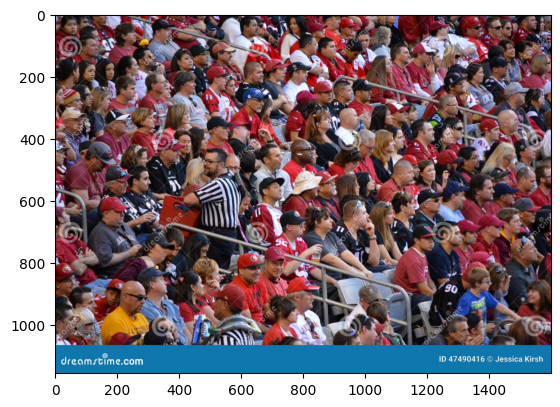

In [ ]:
# Imagen de prueba
#!wget "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fthumbs.dreamstime.com%2Fz%2Fcrowd-people-football-game-sitting-stadium-seats-47490416.jpg&f=1&nofb=1&ipt=e0040288aa8e05d71dca9b50bb6138300bf83aeea52efb370e7277ce16c07332"

# Aca flashee un poco, porque estoy bypasseando el input. Se necesita la img
# en un array para model.predict
# config.DRIVE_
IN = './genteRandom'
im_path = IN + '.jpg'
im_array = img_to_array(load_img(im_path, target_size = (Config.IN_H, Config.IN_W)))
im_array/= 255.0
im_array[:,:,0]=(im_array[:,:,0]-np.mean(im_array[:,:,0]))/np.std(im_array[:,:,0])
im_array[:,:,1]=(im_array[:,:,1]-np.mean(im_array[:,:,1]))/np.std(im_array[:,:,1])
im_array[:,:,2]=(im_array[:,:,2]-np.mean(im_array[:,:,2]))/np.std(im_array[:,:,2])

# Esto debe ser igual a la función predict_count_for_image
# pero elimino pred_map de la salida
model = load_model(config.DRIVE_WEIGHTS)
model.summary()

OUT_X, OUT_Y = 96, 128
output = model.predict(tf.expand_dims(im_array, axis = 0))
output = np.reshape(output, (OUT_X, OUT_Y))

# Imprimir personas y la img
print("Cantidad de personas estimada: ", np.sum(output))
im_display = load_img(im_path)
plt.imshow(im_display)
plt.show()

# PREDICCIÓN Y EVALUACIÓN

In [ ]:
def predict_count_for_image(model, image_path):
    """Predicción de conteo con ReLU aplicado"""
    img = preprocess_image_for_vgg(image_path, target_size=(config.IN_H, config.IN_W))
    pred_map = model.predict(np.expand_dims(img, 0), verbose=0)[0]
    pred_map = np.squeeze(pred_map)
    pred_map = np.maximum(pred_map, 0)  # ReLU para evitar negativos
    return np.sum(pred_map), pred_map

In [ ]:
predict_count_for_image(model, config.DRIVE_IMG)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/IA/Imagenes/'

In [ ]:
def visualize_results(model, num_images=None):
    """Visualización mejorada con layout vertical (una imagen por fila)"""
    if num_images is None:
        num_images = config.NUM_TEST_IMAGES

    print(f"\n=== Evaluación visual en {num_images} imágenes aleatorias ===")

    img_files = [f for f in os.listdir(config.TRAIN_IMG_DIR) if f.endswith('.jpg')]
    if len(img_files) < num_images:
        print(f"Solo hay {len(img_files)} imágenes disponibles, usando todas")
        num_images = len(img_files)

    selected_files = random.sample(img_files, num_images)
    results = []

    # Configurar figura vertical
    fig_height = config.FIGURE_HEIGHT_PER_ROW * num_images
    fig, axes = plt.subplots(num_images, 4, figsize=(config.FIGURE_WIDTH, fig_height))
    fig.suptitle(f'Evaluación: Real vs Predicho ({num_images} imágenes)', fontsize=16, y=0.98)

    # Asegurar que axes sea 2D incluso con una imagen
    if num_images == 1:
        axes = axes.reshape(1, -1)

    for i, filename in enumerate(selected_files):
        # Obtener datos reales
        mat_path = os.path.join(config.TRAIN_GT_DIR, "GT_" + os.path.splitext(filename)[0] + ".mat")
        _, real_count = generate_density_from_mat(mat_path)

        # Predicción
        img_path = os.path.join(config.TRAIN_IMG_DIR, filename)
        pred_count, pred_map = predict_count_for_image(model, img_path)

        # Guardar resultados
        results.append({
            'Imagen': filename,
            'Real': real_count,
            'Predicho': int(round(pred_count)),
            'Error': abs(real_count - pred_count),
            'Error_%': (abs(real_count - pred_count) / max(real_count, 1)) * 100
        })

        # Columna 1: Imagen original
        img_display = load_img(img_path, target_size=(config.IN_H, config.IN_W))
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f'{filename}', fontsize=10, fontweight='bold')
        axes[i, 0].axis('off')

        # Columna 2: Mapa de densidad
        im = axes[i, 1].imshow(pred_map, cmap='hot', aspect='auto')
        axes[i, 1].set_title('Mapa de densidad', fontsize=10)
        axes[i, 1].axis('off')
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

        # Columna 3: Conteo real
        axes[i, 2].text(0.5, 0.5, f'REAL\n{real_count}',
                       ha='center', va='center', fontsize=16, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8),
                       transform=axes[i, 2].transAxes)
        axes[i, 2].set_xlim(0, 1)
        axes[i, 2].set_ylim(0, 1)
        axes[i, 2].axis('off')

        # Columna 4: Conteo predicho con color según precisión
        error_pct = (abs(real_count - pred_count) / max(real_count, 1)) * 100
        if error_pct <= 15:
            color = "lightgreen"
        elif error_pct <= 30:
            color = "lightyellow"
        else:
            color = "lightcoral"

        axes[i, 3].text(0.5, 0.5, f'PREDICHO\n{pred_count:.0f}\n(±{error_pct:.1f}%)',
                       ha='center', va='center', fontsize=16, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.8),
                       transform=axes[i, 3].transAxes)
        axes[i, 3].set_xlim(0, 1)
        axes[i, 3].set_ylim(0, 1)
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

    # Tabla de resultados con pandas
    df_results = pd.DataFrame(results)
    print("\n=== RESUMEN DETALLADO ===")
    print(df_results.to_string(index=False, float_format='%.1f'))

    # Estadísticas finales
    mae = df_results['Error'].mean()
    rmse = np.sqrt(np.mean(df_results['Error']**2))
    mean_error_pct = df_results['Error_%'].mean()

    print(f"\n=== MÉTRICAS DE RENDIMIENTO ===")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"Error promedio: {mean_error_pct:.1f}%")

    # Análisis de tendencias
    overestimate_count = sum(1 for r in results if r['Predicho'] > r['Real'])
    print(f"Sobreestimaciones: {overestimate_count}/{num_images} ({overestimate_count/num_images*100:.1f}%)")

    return df_results

# EJECUCIÓN PRINCIPAL



In [ ]:
print("=== CONFIGURACIÓN ACTUAL ===")
print(f"Imágenes entrada: {config.IN_H}x{config.IN_W}")
print(f"Mapas salida: {config.OUT_H}x{config.OUT_W}")
print(f"Epochs fase 1: {config.EPOCHS}, fase 2: {config.FINE_TUNE_EPOCHS}")
print(f"Learning rates: {config.LEARNING_RATE} -> {config.FINE_TUNE_LR}")
print(f"Parámetros densidad: beta={config.BETA}, sigma={config.SIGMA}")

# Entrenamiento
model, history = train()

# Evaluación visual
results_df = visualize_results(model, num_images=config.NUM_TEST_IMAGES)

=== CONFIGURACIÓN ACTUAL ===
Imágenes entrada: 768x1024
Mapas salida: 96x128
Epochs fase 1: 10, fase 2: 12
Learning rates: 4e-05 -> 4e-06
Parámetros densidad: beta=0.2, sigma=3
=== Cargando datasets ===


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ia-competencia/part_B_final/train_data/images/'